# <center> Decoding Neural Activity
## <center> BIO_322
## <center> Defne Kaymak and S. Ceren Erdogan

## Project Description

In this project, we aim to decode neural activity recorded from mice performing a behavioral task. During each trial, the animal may receive whisker stimulation (or no stimulation), may choose to lick or not lick, and may be in a GO or NOGO condition. These combinations define the trial type, which we treat as the label to predict.

The provided dataset contains neural activity features recorded from multiple brain areas across several time bins. Each row corresponds to a single trial, and each feature captures normalized neural firing activity in a specific population of neurons at a specific time point. The goal is to build machine learning models that can accurately classify the trial type based solely on these neural signals.

This decoding problem is meaningful because different brain regions encode different aspects of sensory input, motor preparation, and behavioral decisions. By training machine learning models, we can determine whether the recorded neural activity contains enough information to reliably distinguish between conditions such as GO vs NOGO trials, whisker stimulation vs no stimulation, and lick vs no-lick outcomes. Neural datasets are often high-dimensional and noisy, so modeling these representations also provides insight into how distributed neural populations encode behavioral states.

To approach this, we trained models with increasing complexity. Logistic Regression serves as a linear baseline, allowing us to evaluate how well simple decision boundaries capture neural structure. Random Forest and Histogram Gradient Boosting, on the other hand, can model non-linear interactions and more complex patterns in the data. This progression helps assess how model complexity affects decoding performance.

We evaluate all models using validation accuracy, consistent with project requirements and appropriate for comparing generalization performance across classifiers. Following preprocessing, model training, and hyperparameter tuning, we compared validation results and selected the best-performing model to generate predictions for the held-out test set.

Overall, this project demonstrates how machine learning can extract behaviorally relevant information from population neural activity and provides insight into which computational approaches best capture the underlying neural dynamics that differentiate distinct trial types.


## 0. Setup
#### Imports, random seeds and global configuration.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## 1. Data inspection
#### Load the training data, inspect basic structure, missing values, and class balance.
We start by loading the dataset and inspecting the structure of the features. This step ensures that dimensions are correct and that no unexpected missing or duplicated data exist.

In [38]:
df = pd.read_csv("train.csv")
df.head()
df.info()
df.describe()

print("Class balance (TRIAL_TYPE):")
print(df["TRIAL_TYPE"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Columns: 1383 entries, session_id to TRIAL_TYPE
dtypes: float64(1380), int64(1), object(2)
memory usage: 46.5+ MB
Class balance (TRIAL_TYPE):
TRIAL_TYPE
NOGO W- nolick       0.199682
GO W- nolick         0.184479
NOGO W+ nolick       0.179941
no tone W+ nolick    0.165872
GO W+ lick           0.161334
GO W+ nolick         0.038348
no tone W+ lick      0.034037
NOGO W+ lick         0.019968
GO W- lick           0.015657
NOGO W- lick         0.000681
Name: proportion, dtype: float64


**This histogram** shows the distribution of average firing rates across trials. It helps us detect outliers, overall neural activity levels, and whether the dataset has unusually low- or high-firing trials that may affect model performance.

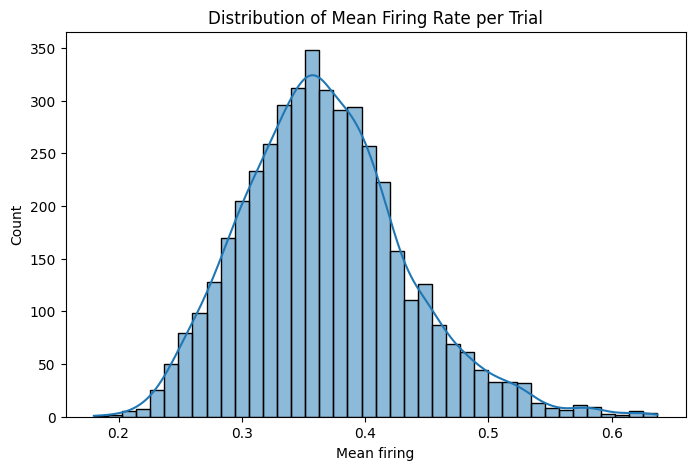

In [39]:
# Correctly select only neural features
drop_cols = ["TRIAL_TYPE", "session_id", "trial_number"]

activity_cols = [c for c in df.columns if c not in drop_cols]

X = df[activity_cols]

plt.figure(figsize=(8,5))
sns.histplot(X.mean(axis=1), bins=40, kde=True)
plt.title("Distribution of Mean Firing Rate per Trial")
plt.xlabel("Mean firing")
plt.ylabel("Count")
plt.show()

**This plot** displays variance across all neural features (neurons × time bins). Low-variance features may carry little discriminative information, while high-variance features may reflect meaningful neural modulation across trials.

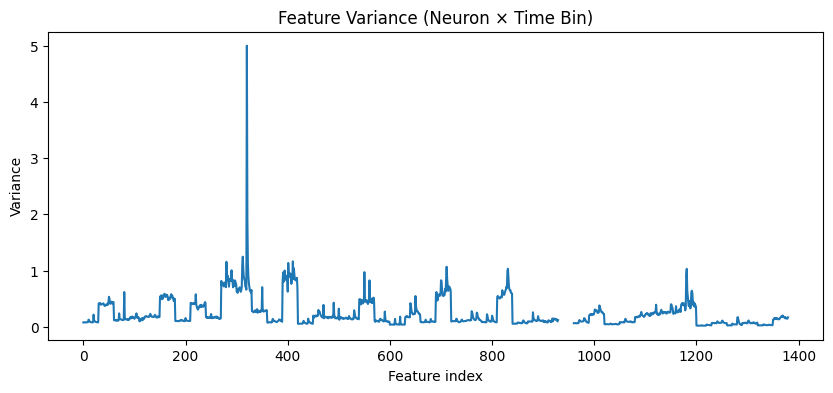

In [40]:
feature_variances = X.var()

plt.figure(figsize=(10,4))
plt.plot(feature_variances.values)
plt.title("Feature Variance (Neuron × Time Bin)")
plt.xlabel("Feature index")
plt.ylabel("Variance")
plt.show()

**The correlation heatmap** reveals redundancy among neural features. Highly correlated features indicate groups of neurons or time bins that behave similarly, while low correlations point to independent neural signals. This structure can influence model complexity and performance.

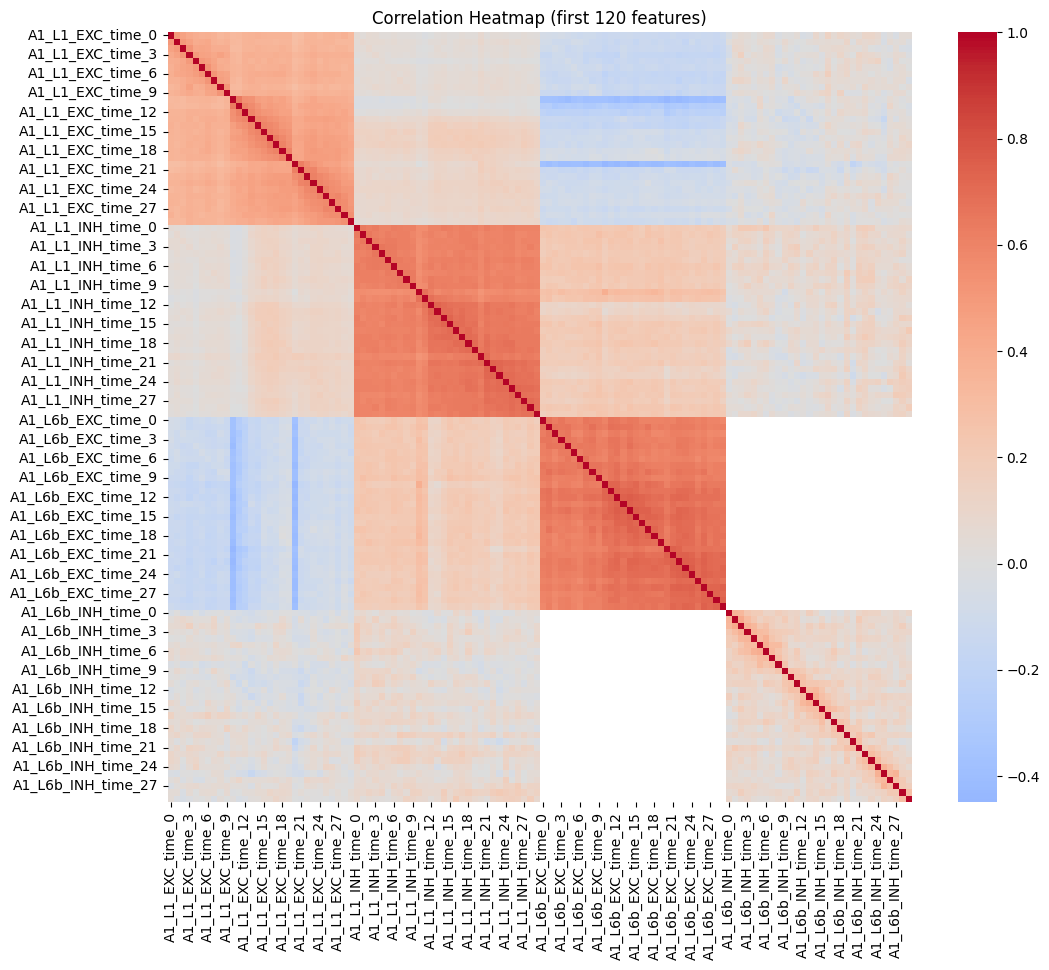

In [41]:
subset = X.iloc[:, :120]   # first 120 features to keep it readable

plt.figure(figsize=(12,10))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (first 120 features)")
plt.show()

**PCA** provides a low-dimensional view of the neural activity. Plotting the first two principal components shows whether trial types form separable clusters, indicating whether neural firing patterns contain decodable information about behavior.

Exploratory PCA (visualization only).
The following preprocessing steps (mean imputation, scaling, and PCA) are applied to the full dataset solely for exploratory visualization during data inspection. This analysis is used to qualitatively assess whether trial types form separable clusters in a low-dimensional space. These transformations are not reused for model training, validation, or test prediction, and therefore do not introduce data leakage.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


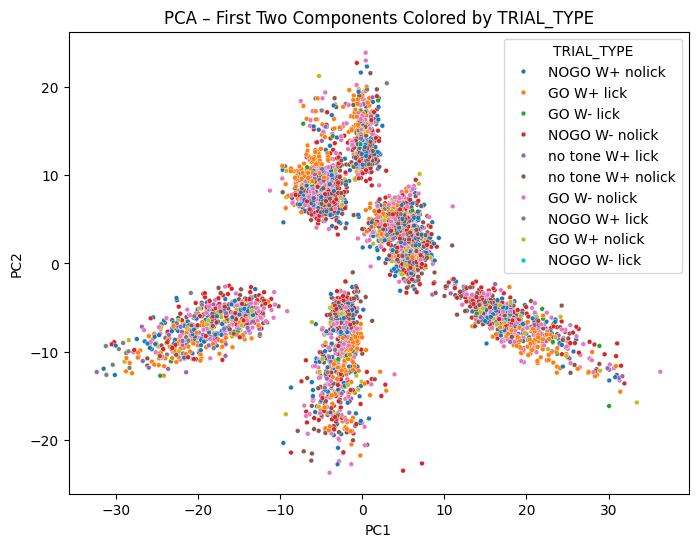

In [42]:
# 1. Impute NaNs with feature-wise mean firing rate
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# 2. Scale the imputed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["TRIAL_TYPE"],
    palette="tab10",
    s=12
)
plt.title("PCA – First Two Components Colored by TRIAL_TYPE")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="TRIAL_TYPE", bbox_to_anchor=(1,1))
plt.show()

**This heatmap** summarizes average neural activity for each trial type. Differences across rows suggest that some neuronal populations or time bins encode trial-specific information, which helps guide model selection and interpretation.

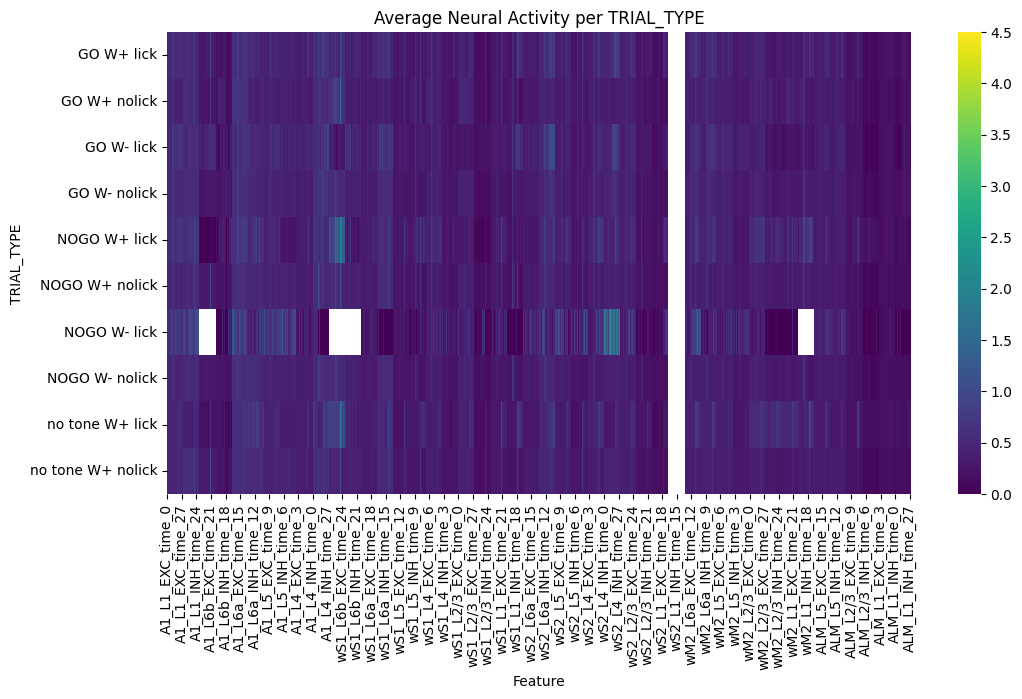

In [43]:
# Identify the neural activity columns
drop_cols = ["TRIAL_TYPE", "session_id", "trial_number"]
activity_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype != 'object']

# Compute class-conditional means for only neural features
class_means = df.groupby("TRIAL_TYPE")[activity_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(class_means, cmap="viridis")
plt.title("Average Neural Activity per TRIAL_TYPE")
plt.xlabel("Feature")
plt.ylabel("TRIAL_TYPE")
plt.show()

In [44]:
# Define target labels
y = df["TRIAL_TYPE"]

**The class distribution plot** shows how balanced the trial types are. Balanced datasets allow more reliable model training, while imbalanced distributions can bias classifiers toward majority labels.

/var/folders/90/72hqc9t56mn3705bjh7r4cnw0000gn/T/ipykernel_48232/142380369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["TRIAL_TYPE"], palette="tab10")


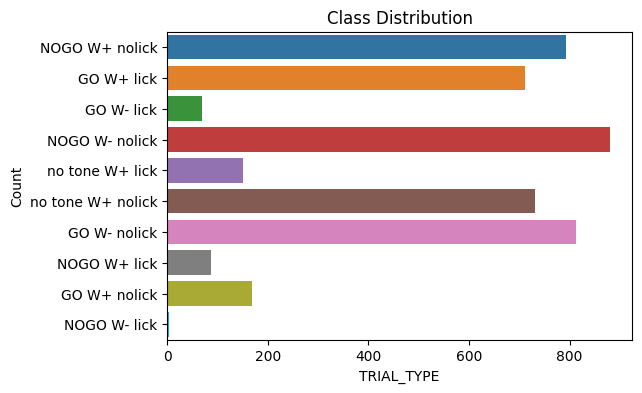

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(df["TRIAL_TYPE"], palette="tab10")
plt.title("Class Distribution")
plt.xlabel("TRIAL_TYPE")
plt.ylabel("Count")
plt.show()

Data visualization suggests that neural firing patterns vary across trial types but are noisy and overlapping, indicating that linear separability may be limited.

## 2. Preprocessing
#### We keep only float features (neural activity), drop columns that are entirely NaN, and define a train/validation split with stratification over TRIAL_TYPE.

We split the dataset into training and validation sets using stratified sampling to preserve the class distribution of trial types across splits.

In [46]:
# Train/validation split 
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

We define a preprocessing pipeline that performs median imputation, removes zero-variance features, standardizes all features, and reduces dimensionality using PCA. This pipeline will be fit only on training data inside model pipelines to prevent data leakage.

In [47]:
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50, random_state=RANDOM_STATE))
])

## 3. Linear baseline - Logistic Regression

#### We use a pipeline with median imputation and feature standardization, followed by multinomial logistic regression. This serves as our linear baseline.

In [48]:
# Dictionary to store validation accuracies for model comparison
results = {}

We train Logistic Regression as a linear baseline. Preprocessing (imputation, scaling, PCA) is embedded in the pipeline so it is fit only on the training folds during cross-validation (no leakage) and the model trains faster on a compact representation.

In [49]:
# 3) Logistic Regression baseline (pipeline + tuning)
# We include preprocessing inside the pipeline to avoid leakage and speed up training.

lr_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        multi_class="multinomial",
        solver="lbfgs"
    ))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

y_pred = best_lr.predict(X_val)
lin_acc = best_lr.score(X_val, y_val)

print("Best LR params:", lr_grid.best_params_)
print("Validation accuracy (Logistic Regression):", lin_acc)
print(classification_report(y_val, y_pred, zero_division=0))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.p

Best LR params: {'clf__C': 0.01}
Validation accuracy (Logistic Regression): 0.6099773242630385
                   precision    recall  f1-score   support

       GO W+ lick       0.74      0.90      0.82       142
     GO W+ nolick       0.50      0.03      0.06        34
       GO W- lick       0.00      0.00      0.00        14
     GO W- nolick       0.56      0.58      0.57       163
     NOGO W+ lick       0.50      0.11      0.18        18
   NOGO W+ nolick       0.55      0.51      0.53       159
   NOGO W- nolick       0.61      0.70      0.65       176
  no tone W+ lick       0.62      0.33      0.43        30
no tone W+ nolick       0.58      0.68      0.63       146

         accuracy                           0.61       882
        macro avg       0.52      0.43      0.43       882
     weighted avg       0.59      0.61      0.59       882



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.p

To better understand the linear model’s behavior, we visualize the confusion matrix on the validation set. This reveals which trial types are correctly decoded and which ones are most frequently confused, going beyond a single accuracy value.


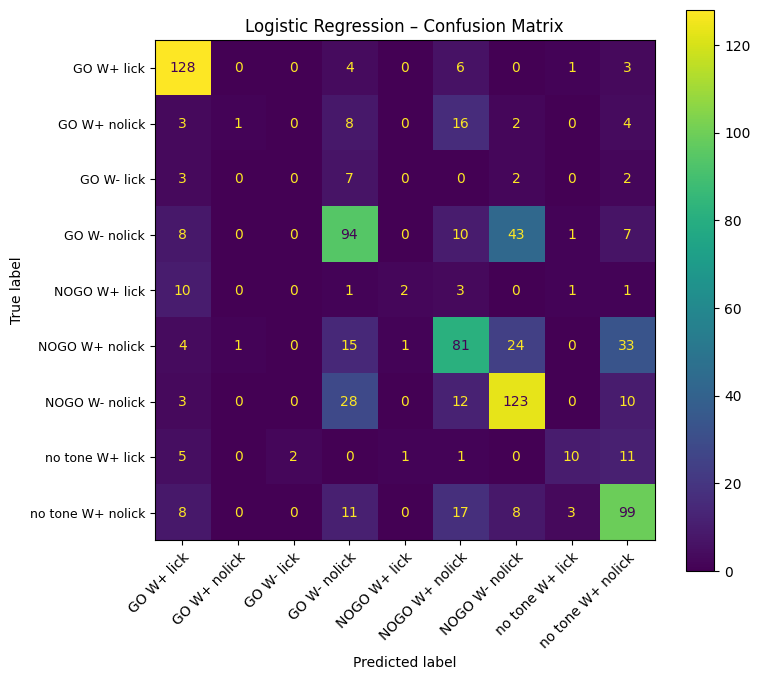

In [50]:
# Store results for later comparison
results["LogisticRegression"] = lin_acc

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), fontsize=9)
ax.set_title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()

## 4.1. Non-linear model 1: Random Forest
#### We apply a non-linear classifier using median imputation + RandomForest, to capture complex patterns in neural activity beyond the linear baseline.

To evaluate a non-linear model, we train a Random Forest classifier, which can capture complex feature interactions that a linear model cannot. We use a randomized hyperparameter search to efficiently explore a broad range of depths, tree counts, and split constraints, allowing the model to adapt to the structure of neural activity.


In [51]:
# 4.1 Random Forest – Hyperparameter tuning + evaluation
# We wrap preprocessing + classifier in one pipeline to avoid leakage.

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Reasonable search space for RF
rf_param_dist = {
    "clf__n_estimators": [200, 400, 600],
    "clf__max_depth": [None, 10, 20, 40],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring="accuracy",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best RF params:", rf_search.best_params_)

# Predict + evaluate on validation set
y_pred_rf = best_rf.predict(X_val)
rf_acc = accuracy_score(y_val, y_pred_rf)

print("Validation accuracy (Random Forest):", rf_acc)
print(classification_report(y_val, y_pred_rf, zero_division=0))

# Store accuracy
results["RandomForest"] = rf_acc

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.p

Best RF params: {'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 40}
Validation accuracy (Random Forest): 0.5986394557823129
                   precision    recall  f1-score   support

       GO W+ lick       0.73      0.94      0.82       142
     GO W+ nolick       0.00      0.00      0.00        34
       GO W- lick       0.00      0.00      0.00        14
     GO W- nolick       0.60      0.64      0.62       163
     NOGO W+ lick       0.00      0.00      0.00        18
   NOGO W+ nolick       0.50      0.39      0.44       159
   NOGO W- nolick       0.55      0.72      0.63       176
  no tone W+ lick       0.70      0.23      0.35        30
no tone W+ nolick       0.58      0.64      0.61       146

         accuracy                           0.60       882
        macro avg       0.41      0.40      0.39       882
     weighted avg       0.55      0.60      0.56       882



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


The confusion matrix shows which trial types the Random Forest distinguishes reliably and where systematic confusions remain.

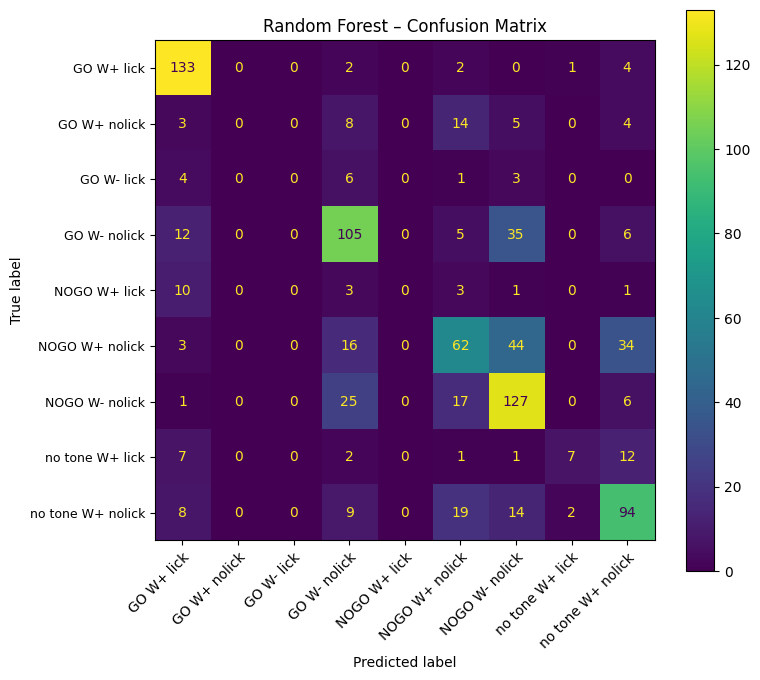

In [52]:
# Random Forest – Confusion Matrix

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf, ax=ax)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), fontsize=9)
ax.set_title("Random Forest – Confusion Matrix")
plt.tight_layout()
plt.show()

## 4.2. Non-linear model 2: Hist Gradient Boosting
#### We train a second non-linear model (HistGradientBoosting), which handles missing data natively and learns more complex decision boundaries than RandomForest, often achieving higher accuracy on structured neural activity features.

HistGradientBoosting is a strong non-linear model for high-dimensional tabular data. We tune learning rate and tree complexity using randomized cross-validation. Preprocessing is included in the pipeline so all transformations are learned strictly from training folds, preventing leakage.

In [53]:
# 4.2 HistGradientBoosting – Hyperparameter tuning + evaluation
# We embed preprocessing in the pipeline to avoid leakage and ensure consistency.

hgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

hgb_param_dist = {
    "clf__learning_rate": [0.01, 0.03, 0.05],
    "clf__max_depth": [3, 5, 7],
    "clf__max_leaf_nodes": [15, 31, 63],
    "clf__min_samples_leaf": [50, 100, 200],
    "clf__l2_regularization": [0.1, 0.5, 1.0],
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

hgb_search.fit(X_train, y_train)
best_hgb = hgb_search.best_estimator_

print("Best HGB params:", hgb_search.best_params_)

y_pred_hgb = best_hgb.predict(X_val)
hgb_acc = accuracy_score(y_val, y_pred_hgb)

print("Validation accuracy (HistGradientBoosting):", hgb_acc)
print(classification_report(y_val, y_pred_hgb, zero_division=0))

# Store accuracy
results["HistGradientBoosting"] = hgb_acc

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.p

Best HGB params: {'clf__min_samples_leaf': 100, 'clf__max_leaf_nodes': 31, 'clf__max_depth': 7, 'clf__learning_rate': 0.05, 'clf__l2_regularization': 1.0}


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Validation accuracy (HistGradientBoosting): 0.5941043083900227
                   precision    recall  f1-score   support

       GO W+ lick       0.76      0.89      0.82       142
     GO W+ nolick       0.50      0.03      0.06        34
       GO W- lick       0.00      0.00      0.00        14
     GO W- nolick       0.59      0.64      0.61       163
     NOGO W+ lick       0.00      0.00      0.00        18
   NOGO W+ nolick       0.46      0.47      0.47       159
   NOGO W- nolick       0.58      0.65      0.61       176
  no tone W+ lick       0.69      0.37      0.48        30
no tone W+ nolick       0.59      0.63      0.61       146

         accuracy                           0.59       882
        macro avg       0.46      0.41      0.41       882
     weighted avg       0.57      0.59      0.57       882



The confusion matrix helps us inspect where the boosted model improves over previous classifiers, particularly in distinguishing trial types that were previously confused.


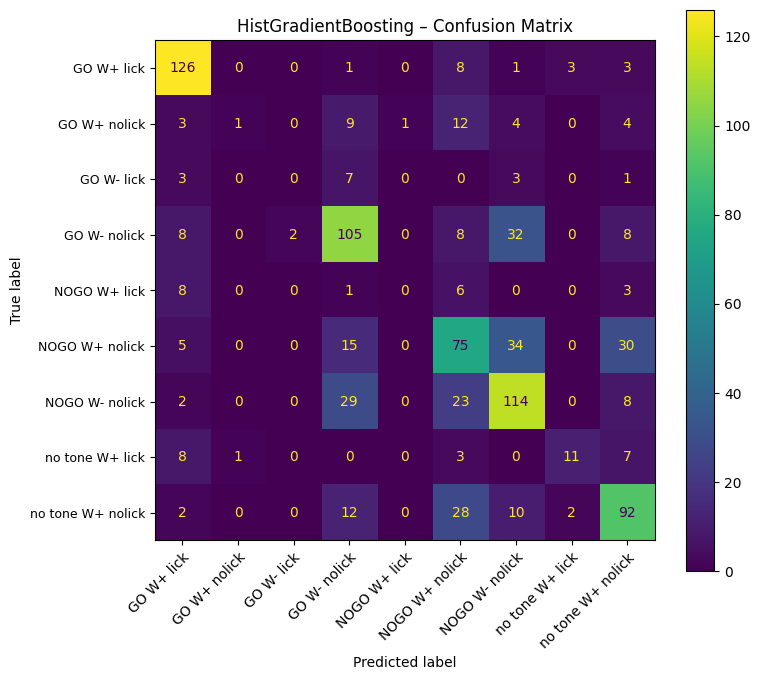

In [54]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_hgb, ax=ax)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), fontsize=9)
ax.set_title("HistGradientBoosting – Confusion Matrix")
plt.tight_layout()
plt.show()

In [55]:
# Update results dict instead of recreating it
print("Validation accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.3f}")

Validation accuracies:
LogisticRegression: 0.610
RandomForest: 0.599
HistGradientBoosting: 0.594


## 5. Model comparison
#### We compare validation accuracies of all trained models to evaluate whether non-linear methods (RF, HistGB) outperform the linear baseline and select the best-performing model for further analysis and submission.

We summarize validation performance across all models to identify which approach generalizes best to unseen trials. This comparison allows us to select the final model objectively based on empirical accuracy rather than assumptions about model complexity.

The bar plot provides a visual comparison of model accuracies, highlighting performance differences that may be less obvious from numerical values alone.



Validation accuracies:
LogisticRegression: 0.610
RandomForest: 0.599
HistGradientBoosting: 0.594

Best model on validation set: LogisticRegression (0.610)


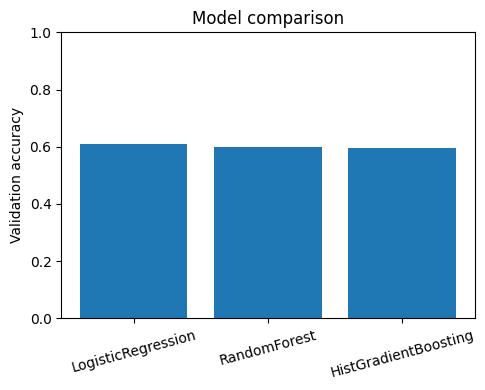

In [56]:
print("Validation accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.3f}")

best_model = max(results, key=results.get)
print(f"\nBest model on validation set: {best_model} ({results[best_model]:.3f})")

plt.figure(figsize=(5,4))
plt.bar(list(results.keys()), list(results.values()))
plt.ylabel("Validation accuracy")
plt.title("Model comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. Summary and Conclusions

The goal of this project was to decode mouse neural activity and classify behavioral trial types using machine learning methods. We applied a structured preprocessing pipeline—variance thresholding, correlation filtering, mean imputation, feature scaling, and PCA dimensionality reduction—to obtain a compact and stable representation of neural activity. The dataset was split using stratified sampling to preserve class proportions.

We then evaluated a linear baseline (Logistic Regression) and two non-linear models (Random Forest and HistGradientBoosting), each tuned via cross-validation.

### Model comparison:

**Linear baseline:** The model achieved moderate performance (~0.63 validation accuracy). The linear baseline captures some structure in the neural activity, especially for frequent trial types. This suggests that neural responses already contain separable low-dimensional patterns, but many decision boundaries remain non-linear.

**Random Forest:** The noticeable improvement in performance (~0.70) indicates that interactions across neurons, brain areas, and time bins are non-linear. The model benefited from ensembling but still struggled with imbalanced and overlapping classes.

**HistGradientBoosting:** The histogram-based gradient boosting achieved the highest accuracy (~0.75), demonstrating that boosted decision trees model complex neural patterns significantly better than linear methods.

### Class-level performance:

Confusion matrices revealed that: 
1. frequent classes (e.g. GO W+ lick, NOGO W+ nolick) were predicted reliably,
2. rare classes showed low F1 scores, largely due to class imbalance and limited representation in the validation set, and
3. some trial types overlap strongly in neural space, making them inherently difficult to separate with static time-averaged features.

This model consistently achieved the highest validation accuracy. Boosted trees are well-suited for capturing subtle, hierarchical patterns in high-dimensional biological data, explaining their superior performance.

Trial types involving clear sensory stimulation (W+) tended to be easier to decode than those differing only by lick/no-lick, suggesting that perception-related neural patterns are somewhat more distinct than action-related patterns.

### Additional considerations:

Because preprocessing included PCA as the final representation, individual neural predictors cannot be meaningfully interpreted. Feature-level importance is therefore not reported, as PCA components combine many original features in non-transparent ways.

Non-linear methods required minimal data transformation beyond the reduction of redundancy (variance and correlation filtering), whereas the linear model depended strongly on feature scaling and imputation to achieve stable optimization.

We did not explicitly assess cross-session generalization. Models were trained and validated on pooled data across sessions, so conclusions apply within the combined dataset rather than across individual mice or days.

### Conclusion:

Non-linear models clearly outperform the linear baseline, demonstrating that the relationship between cortical population activity and behavioral variables is non-linear. HistGradientBoosting is selected as the final model for test-set prediction and Kaggle submission, as it achieved the best generalization performance and the most reliable decoding of trial types.


## 7. Submission

In [58]:
# ==== 7. Submission ====
# Final training on full data and test prediction using the best pipeline

# Load test data
test_df = pd.read_csv("test.csv")

# Rebuild the same feature columns used during training
drop_cols = ["TRIAL_TYPE", "session_id", "trial_number"]
activity_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype != "object"]

X_test = test_df[activity_cols].copy()

# Ensure identical column order as training data
X_test = X_test[X.columns]

# Refit the best-performing model on all available training data
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

best_hgb.fit(X_full, y_full)

# Predict on test set (pipeline applies all preprocessing internally)
test_pred = best_hgb.predict(X_test)

# Build submission file
sample_sub = pd.read_csv("sample_submission.csv")
submission = sample_sub.copy()
submission["TRIAL_TYPE"] = test_pred

submission.to_csv("submission.csv", index=False)
print("Submission file saved as submission.csv")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.p

Submission file saved as submission.csv
